## Lagrangian Neural Networks (LNNs) - Solving the double pendulum equation


In [13]:
!pip install jax
!pip install optax
!pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.9 MB/s eta 0:00:00


#### The Lagrangian and numerical solution for the double-pendulum problem
Suppose we are given a a double pendulum with angles $\theta_1$ and $\theta_2$, with respective rods of length $L_1$ and $L_2$

The state vector of the double pendulum is denoted
$$
y =
\begin{bmatrix}
\theta_1 \\
\theta_2 \\
\dot{\theta_1} \\
\dot{\theta_2} \\
\end{bmatrix}, \dot{y} = \frac{dy}{dt}
$$
where $\theta_i$ is the angle of the i'th rod and the downward axis.

Let $\theta$ and $\dot{\theta}$ be the vectors of the angles and their derivatives respectively

We now define the Lagrangian
$$
L(\theta, \dot{\theta}) = T(\theta, \dot{\theta}) - V(\theta)
$$

For the double pendulum, we have
$$
T(\theta, \dot{\theta}) = \frac{1}{2} {\dot{\theta}}^T M(\theta)\dot{\theta} \\
V(\theta) = -(m_1+m_2)gL_1\cos(\theta_1) - m_2 g L_2 \cos(\theta_2) \\
M(\theta)=\begin{bmatrix}
(m_1+m_2)L_1^2 & m_2L_1L_2\cos(\theta_1-\theta_2) \\
m_2L_1L_2\cos(\theta_1-\theta_2) & m_2L_2^2
\end{bmatrix}
$$

Now recall the Euler-Lagrange equation
$$
\frac{d}{dt}(\frac{\partial L}{\partial \dot{\theta}}) - \frac{\partial L}{\partial \theta} = 0
$$

Since $V$ does not depend on $\dot{\theta}$, we get
$$
\frac{\partial L}{\partial \dot{\theta}} = \frac{\partial T}{\partial \dot{\theta}} = M(\theta)\dot{\theta}
$$

after some manipulation
$$
\frac{d}{dt} (M(\theta)\dot{\theta}) = M(\theta)\dot{\dot{\theta}} + \dot{M(\theta)}\dot\theta = b(\theta, \dot{\theta}) + \dot{M(\theta)}\dot\theta
$$

The formula for $b(\theta, \dot{\theta})$ is
$$
\Delta=\theta_1-\theta_2 \\
b(\theta,\dot{\theta})=
\begin{bmatrix}
-m_2L_1L_2\sin(\Delta)\dot{\theta}_2^2-(m_1+m_2)gL_1\sin(\theta_1) \\
m_2L_1L_2\sin(\Delta)\dot{\theta}_1^2-m_2gL_2\sin(\theta_2)
\end{bmatrix}
$$

Using some linear algebra, we finally get
$$
\dot{\dot{\theta}} = M(\theta)^{-1}b(\theta, \dot{\theta})
$$

We now have what we need to implement a numerical solver!


In [5]:
import jax
import jax.numpy as jnp

def M_mat(theta1, theta2, m1, m2, L1, L2):
  c = jnp.cos(theta1 - theta2)
  return jnp.array([
      [(m1 + m2) * L1**2, m2 * L1 * L2 * c],
      [m2 * L1 * L2 * c, m2 * L2**2],
  ])

def b_vec(theta1, theta2, dtheta1, dtheta2, m1, m2, L1, L2, g):
  s = jnp.sin(theta1 - theta2)
  return jnp.array([
      -m2 * L1 * L2 * s * (dtheta2**2) - (m1 + m2) * g * L1 * jnp.sin(theta1),
        m2 * L1 * L2 * s * (dtheta1**2) - m2 * g * L2 * jnp.sin(theta2),
  ])


In [4]:
# y_dot = f(y)
def double_pendulum_rhs(y, params):
  m1, m2, L1, L2, g = params
  theta1, theta2, dtheta1, dtheta2 = y

  M = M_mat(theta1, theta2, m1, m2, L1, L2)
  b = b_vec(theta1, theta2, dtheta1, dtheta2, m1, m2, L1, L2, g)

  ddtheta = jnp.linalg.solve(M, b) # double dot theta

  return jnp.array([dtheta1, dtheta2, ddtheta[0], ddtheta[1]])

# RK4 Step
def rk4_step(y, params, dt):
  k1 = double_pendulum_rhs(y, params)
  k2 = double_pendulum_rhs(y + 0.5 * dt * k1, params)
  k3 = double_pendulum_rhs(y + 0.5 * dt * k2, params)
  k4 = double_pendulum_rhs(y + dt * k3, params)
  return y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# Rollout for lax.scan
def rollout(y0, params, dt, steps):
  def body(y, _):
      y_next = rk4_step(y, params, dt)
      return y_next, y_next

  yT, ys = jax.lax.scan(body, y0, xs=None, length=steps)
  ys = jnp.vstack([y0[None, :], ys])
  return ys

def angles_to_xy(ys, params):
  _, _, L1, L2, _ = params
  theta1 = ys[:, 0]
  theta2 = ys[:, 1]

  x1 = L1 * jnp.sin(theta1)
  y1 = -L1 * jnp.cos(theta1)

  x2 = x1 + L2 * jnp.sin(theta2)
  y2 = y1 - L2 * jnp.cos(theta2)

  return x1, y1, x2, y2

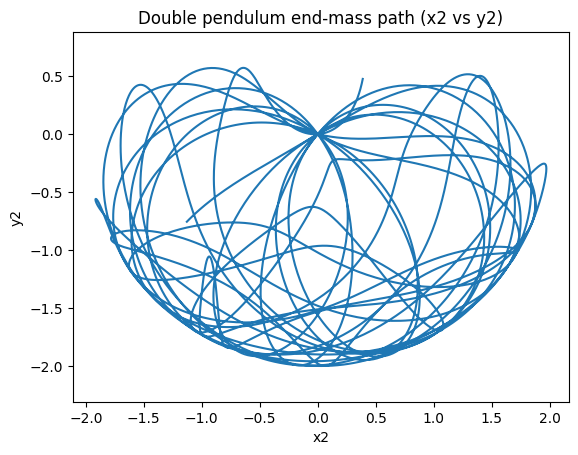

In [28]:
import matplotlib.pyplot as plt

params = (5.0, 1.0, 1.0, 1.0, 9.81)  # (m1,m2,L1,L2,g)

# y0 = [theta1, theta2, dtheta1, dtheta2]
y0 = jnp.array([1.2, 10.0, 0.0, 0.0])

dt = 0.005
steps = 6000

ys = rollout(y0, params, dt, steps)
x1, y1, x2, y2 = angles_to_xy(ys, params)

plt.figure()
plt.plot(jnp.asarray(x2), jnp.asarray(y2))
plt.title("Double pendulum end-mass path (x2 vs y2)")
plt.xlabel("x2")
plt.ylabel("y2")
plt.axis("equal")
plt.show()

## Implementing the Lagrangian Neural Net
The idea of the LNN is simple, instead of solving for $\dot{\dot{\theta}}$, we train a neural net $L_{\phi}(\theta, \dot{\theta}) \in \mathbb{R}$ ($\phi$ are the parameters to the network) that acts as our scalar Lagrangian. This value is then used to derive $\dot{\dot{\theta}}$.

Let's start by generating a dataset for testing from our numerical solver

In [18]:
# TODO: Review this again, vibe coded this part lol

def traj_to_dataset(ys, params):
  # We want to use our numerical solver to create a dataset of trajectories
  ydot = jax.vmap(lambda y: double_pendulum_rhs(y, params))(ys)
  X = ys
  Y = ydot[:, 2:4]
  return X, Y

def sample_y0s(key, n_traj, theta_range=jnp.pi, dtheta_range=1.0):
  k1, k2 = jax.random.split(key)
  thetas  = jax.random.uniform(k1, (n_traj, 2), minval=-theta_range, maxval=theta_range)
  dthetas = jax.random.uniform(k2, (n_traj, 2), minval=-dtheta_range, maxval=dtheta_range)
  return jnp.concatenate([thetas, dthetas], axis=1)  # (n_traj, 4)

def make_trajectory_dataset(key, params, dt, steps, n_traj,
                            theta_range=jnp.pi, dtheta_range=1.0,
                            subsample=2, drop_first=0):
  """
  Returns:
    X: (N,4)
    Y: (N,2)
  """
  # 1) initial conditions
  y0s = sample_y0s(key, n_traj, theta_range, dtheta_range)

  # 2) rollouts in batch: (B, T, 4)
  ys_batch = jax.vmap(lambda y0: rollout(y0, params, dt, steps))(y0s)

  # 3) drop + subsample time to reduce correlation
  ys_batch = ys_batch[:, drop_first::subsample, :]  # (B, T', 4)

  # 4) label each time step with accelerations
  X_batch, Y_batch = jax.vmap(lambda ys: traj_to_dataset(ys, params))(ys_batch)
  # X_batch: (B, T', 4), Y_batch: (B, T', 2)

  # 5) flatten across trajectories and time
  X = X_batch.reshape(-1, 4)
  Y = Y_batch.reshape(-1, 2)
  return X, Y

def shuffle_split(key, X, Y, train_frac=0.9):
  n = X.shape[0]
  perm = jax.random.permutation(key, n)
  X, Y = X[perm], Y[perm]
  n_train = int(train_frac * n)
  return (X[:n_train], Y[:n_train]), (X[n_train:], Y[n_train:])

In [29]:
params = (5.0, 1.0, 1.0, 1.0, 9.81)
dt = 0.005
steps = 2000
n_traj = 256

key = jax.random.PRNGKey(0)
X, Y = make_trajectory_dataset(
    key, params, dt, steps, n_traj,
    theta_range=jnp.pi,     # angles in [-pi, pi]
    dtheta_range=1.0,       # angular velocities in [-1, 1]
    subsample=2,            # keep every 2nd step
    drop_first=10           # optional: skip first few steps
)

(Xtr, Ytr), (Xva, Yva) = shuffle_split(jax.random.PRNGKey(1), X, Y)
print("Train:", Xtr.shape, Ytr.shape)
print("Val:  ", Xva.shape, Yva.shape)

Train: (229478, 4) (229478, 2)
Val:   (25498, 4) (25498, 2)
